## Step 1 : Import Library & Data

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df = pd.read_csv(r"C:\Users\Ankit_\Downloads\Datasets\Gold Futures Historical Data.csv")
df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,10-04-2026,"4,787.40","4,790.50","4,820.00","4,752.70",117.74K,-0.64%
1,09-04-2026,"4,818.00","4,744.80","4,826.00","4,718.60",133.63K,0.85%
2,08-04-2026,"4,777.20","4,747.20","4,888.00","4,720.60",215.12K,1.97%
3,07-04-2026,"4,684.70","4,678.60","4,745.70","4,631.90",145.71K,0.00%
4,06-04-2026,"4,684.70","4,675.00","4,733.10","4,626.20",89.41K,0.11%


In [40]:
df.tail()

,Price,Open,High,Low,Vol.,Change %,Target
Date,,,,,,,
2026-04-02,4679.7,4783.0,4825.9,4580.4,190.44K,-2.77%,4679.7
2026-04-06,4684.7,4675.0,4733.1,4626.2,89.41K,0.11%,4684.7
2026-04-07,4684.7,4678.6,4745.7,4631.9,145.71K,0.00%,4777.2
2026-04-08,4777.2,4747.2,4888.0,4720.6,215.12K,1.97%,4818.0
2026-04-09,4818.0,4744.8,4826.0,4718.6,133.63K,0.85%,4787.4


## Step 2: Clean the Data

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2505 entries, 0 to 2504
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      2505 non-null   object
 1   Price     2505 non-null   object
 2   Open      2505 non-null   object
 3   High      2505 non-null   object
 4   Low       2505 non-null   object
 5   Vol.      2502 non-null   object
 6   Change %  2505 non-null   object
dtypes: object(7)
memory usage: 137.1+ KB


In [24]:
# Convert columns to numeric
for col in ['Price', 'Open', 'High', 'Low']:
    df[col] = df[col].astype(str).str.replace(',', '').astype(float)

# Convert Date
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Sort data
df = df.sort_values(by='Date')

# Set index
df.set_index('Date', inplace=True)

## STEP 4: EDA (Exploratory Data Analysis)

In [25]:
df. info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2505 entries, 2015-01-08 to 2026-04-10
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Price     2505 non-null   float64
 1   Open      2505 non-null   float64
 2   High      2505 non-null   float64
 3   Low       2505 non-null   float64
 4   Vol.      2502 non-null   object 
 5   Change %  2505 non-null   object 
dtypes: float64(4), object(2)
memory usage: 137.0+ KB


In [26]:
df.describe()

,Price,Open,High,Low
count,2505.000000,2505.000000,2505.000000,2505.000000
mean,1841.741669,1841.476826,1856.142786,1826.646232
std,829.910095,829.468515,841.937142,816.706002
min,1049.600000,1051.500000,1062.700000,1045.400000
25%,1272.500000,1271.500000,1279.700000,1264.200000
50%,1717.700000,1722.800000,1733.200000,1703.900000
75%,1940.700000,1943.400000,1955.600000,1924.000000
max,5354.800000,5449.900000,5626.800000,5272.900000


In [27]:
df.isnull().sum()

Price       0
Open        0
High        0
Low         0
Vol.        3
Change %    0
dtype: int64

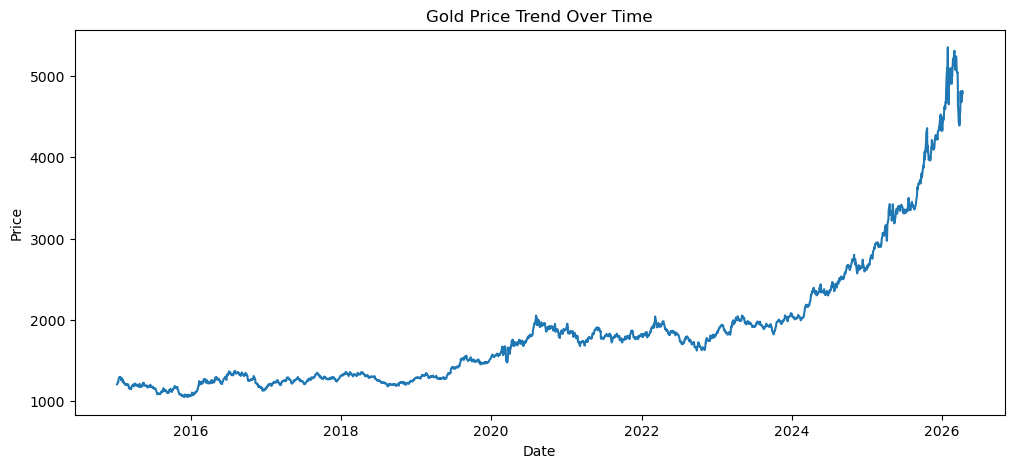

In [28]:
plt.figure(figsize=(12,5))
plt.plot(df['Price'])
plt.title("Gold Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

## STEP 5: Feature Engineering

In [29]:
df['Target'] = df['Price'].shift(-1)

df = df.dropna()

In [30]:
df.head()

,Price,Open,High,Low,Vol.,Change %,Target
Date,,,,,,,
2015-01-08,1208.5,1211.0,1216.8,1204.2,122.49K,-0.18%,1216.1
2015-01-09,1216.1,1208.9,1224.0,1207.0,155.98K,0.63%,1232.8
2015-01-12,1232.8,1223.0,1236.0,1217.5,138.52K,1.37%,1234.4
2015-01-13,1234.4,1233.1,1244.5,1227.4,179.65K,0.13%,1234.5
2015-01-14,1234.5,1231.2,1244.6,1224.9,193.11K,0.01%,1264.8


## STEP 6: Feature Selection

In [31]:
X = df[['Open', 'High', 'Low']]
y = df['Target']

## STEP 7: Train-Test Split (Time-Based) 

In [32]:
train_size = int(len(df) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [33]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2000, 3)
(501, 3)
(2000,)
(501,)


## STEP 8: Model + Scaling 

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

model = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('lr', LinearRegression())])

## STEP 9: Prediction & Evaluation 

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 37.354249350310305
MSE: 3846.7993090877053
R2: 0.9956575859423973


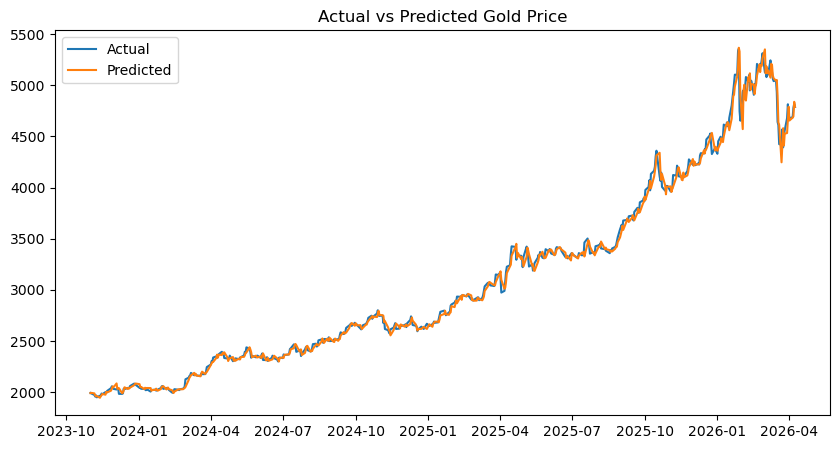

In [36]:
plt.figure(figsize=(10,5))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, y_pred, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Gold Price")
plt.show()

In [37]:
X_test.head()

,Open,High,Low
Date,,,
2023-11-01,1993.3,2005.9,1978.2
2023-11-02,1992.0,1999.2,1986.3
2023-11-06,1999.4,2000.1,1984.2
2023-11-07,1984.8,1985.2,1962.8
2023-11-08,1975.3,1977.5,1953.2


In [38]:
y_test.head()

Date
2023-11-01    1993.5
2023-11-02    1988.6
2023-11-06    1973.5
2023-11-07    1957.8
2023-11-08    1969.8
Name: Target, dtype: float64

## Future Prediction

In [20]:

# Input from user
open_price = float(input("Enter Open: "))
high_price = float(input("Enter High: "))
low_price = float(input("Enter Low: "))

new_data = pd.DataFrame({
    'Open': [open_price],
    'High': [high_price],
    'Low': [low_price]
})

prediction = model.predict(new_data)

print("📅 Predicted Next Day Price:", prediction[0])

Enter Open: 1993.3
Enter High: 2005.9
Enter Low: 1978.2
📅 Predicted Next Day Price: 1991.8825846780428
